In [4]:
%matplotlib inline
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))


In [5]:
import importlib
import src.calibration
importlib.reload(src.calibration)

cal, diagrams = src.calibration.run()
cal.round(4)

A_tfidf        T=0.567  ECE 0.1577 -> 0.0171  mean_conf 0.730 -> 0.898  acc 0.8871 -> 0.8871
B_minilm       T=0.575  ECE 0.1450 -> 0.0117  mean_conf 0.776 -> 0.919  acc 0.9214 -> 0.9214
C_distilbert   T=0.950  ECE 0.0212 -> 0.0166  mean_conf 0.924 -> 0.935  acc 0.9207 -> 0.9207


,track,temperature,mean_conf_before,mean_conf_after,accuracy,accuracy_after,ece_before,ece_after,msp_auroc_ood_before,msp_auroc_ood_after,msp_auroc_idoos_before,msp_auroc_idoos_after
0,A_tfidf,0.5673,0.7295,0.8978,0.8871,0.8871,0.1577,0.0171,0.9586,0.9411,0.8618,0.8509
1,B_minilm,0.5745,0.7764,0.9192,0.9214,0.9214,0.1450,0.0117,0.9765,0.9568,0.9198,0.9049
2,C_distilbert,0.9502,0.9245,0.9347,0.9207,0.9207,0.0212,0.0166,0.9769,0.9756,0.9001,0.8993


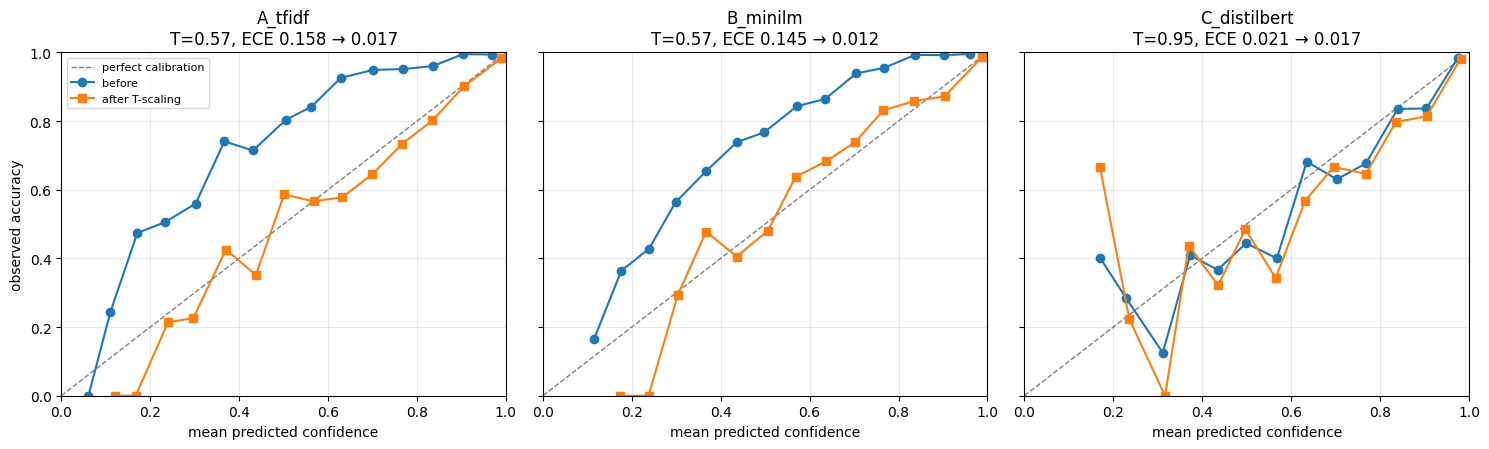

In [6]:
import matplotlib.pyplot as plt
from src import config

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)

for ax, (track, (before, after)) in zip(axes, diagrams.items()):
    ax.plot([0, 1], [0, 1], ls="--", c="grey", lw=1, label="perfect calibration")
    for diag, label, marker in [(before, "before", "o"), (after, "after T-scaling", "s")]:
        d = diag.dropna(subset=["confidence"])
        ax.plot(d["confidence"], d["accuracy"], marker=marker, label=label)
    row = cal[cal["track"] == track].iloc[0]
    ax.set_title(f"{track}\nT={row['temperature']:.2f}, "
                 f"ECE {row['ece_before']:.3f} → {row['ece_after']:.3f}")
    ax.set_xlabel("mean predicted confidence")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("observed accuracy")
axes[0].legend(loc="upper left", fontsize=8)
plt.tight_layout()
fig.savefig(config.FIGURES_DIR / "calibration.png", dpi=150)
plt.show()